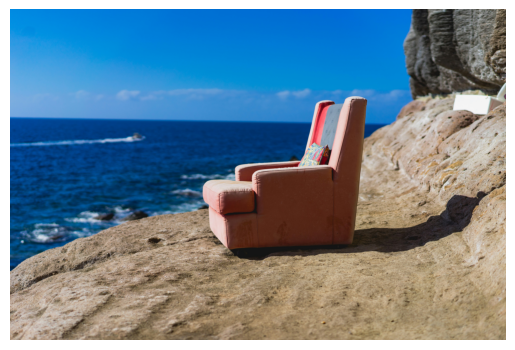

Loading Image Captioning Model...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  990MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  990MB            

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
# Install required libraries
!pip install -q transformers torch pillow requests sentencepiece

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    BlipForQuestionAnswering
)
from PIL import Image
import requests
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load Image
# ---------------------------------------------------

image_url = "https://images.unsplash.com/photo-1519125323398-675f0ddb6308"

raw_image = Image.open(
    requests.get(image_url, stream=True).raw
).convert("RGB")

# Display image
plt.imshow(raw_image)
plt.axis("off")
plt.show()

# ---------------------------------------------------
# Image Captioning
# ---------------------------------------------------

print("Loading Image Captioning Model...")

cap_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

cap_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

inputs = cap_processor(images=raw_image, return_tensors="pt")

caption_ids = cap_model.generate(
    **inputs,
    max_new_tokens=30
)

caption = cap_processor.decode(
    caption_ids[0],
    skip_special_tokens=True
)

print("\nGenerated Caption:")
print(caption)

# ---------------------------------------------------
# Visual Question Answering (VQA)
# ---------------------------------------------------

print("\nLoading VQA Model...")

vqa_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-vqa-base"
)

vqa_model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base"
)

question = "What animal is in the picture?"

vqa_inputs = vqa_processor(
    images=raw_image,
    text=question,
    return_tensors="pt"
)

answer_ids = vqa_model.generate(**vqa_inputs)

answer = vqa_processor.decode(
    answer_ids[0],
    skip_special_tokens=True
)

print("\nQuestion:", question)
print("Answer:", answer)